In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Distorted Visual Sequence Pattern Recognition
## Data Exploration

The dataset used in this project consists of images containing distorted visual sequences along with their corresponding labels. Since the primary objective is to recognize these sequences despite the presence of noise and visual distortions, understanding the characteristics of the dataset is an important first step before building any model.

In this notebook, the training and test datasets are explored to gain insights into their structure and contents. This includes examining the distribution of labels, inspecting image dimensions, and visualizing sample images from different parts of the dataset. Such analysis helps in identifying patterns, inconsistencies, and potential challenges that may affect model performance.

Special attention is given to the types of distortions present in the images, variations in sequence lengths, and the overall diversity of the data. Understanding these factors can provide useful guidance for preprocessing, feature extraction, and model selection in later stages of the project.

The notebook concludes with a summary of the key observations obtained during the exploration phase, which will serve as a foundation for the subsequent development of a robust sequence recognition system.

In [ ]:
# Purpose: Import required libraries and automatically locate dataset files and directories.

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

root = Path.cwd()
possible_roots = [root / 'cig_ps', root / 'dataset', root]

train_csv = None
train_dir = None
test_dir = None

CSV_NAMES = ['train-labels.csv', 'train_labels.csv', 'labels.csv']
TRAIN_DIR_NAMES = ['train_images', 'train/images', 'train']
TEST_DIR_NAMES = ['test_images', 'test/images', 'test']

for candidate in possible_roots:
    for csv_name in CSV_NAMES:
        p = candidate / csv_name
        if p.exists():
            train_csv = p
            break

    for d in TRAIN_DIR_NAMES:
        p = candidate / d
        if p.exists() and p.is_dir():
            train_dir = p
            break

    for d in TEST_DIR_NAMES:
        p = candidate / d
        if p.exists() and p.is_dir():
            test_dir = p
            break

    if train_csv and train_dir and test_dir:
        break

print("Resolved Dataset Paths:")
print("  Training Labels :", train_csv)
print("  Training Images :", train_dir)
print("  Test Images     :", test_dir)

assert train_csv is not None, (
    "Training label file could not be located. "
    "Please verify the dataset directory structure."
)

assert train_dir is not None, (
    "Training image directory could not be located."
)

assert test_dir is not None, (
    "Test image directory could not be located."
)

print("\nDataset paths resolved successfully.")

Resolved Dataset Paths:
  Training Labels : /home/anirudh/Desktop/cigproject/cig_ps/train-labels.csv
  Training Images : /home/anirudh/Desktop/cigproject/cig_ps/train_images
  Test Images     : /home/anirudh/Desktop/cigproject/cig_ps/test_images

Dataset paths resolved successfully.


In [ ]:
# Purpose: Verify dataset structure and inspect the contents of discovered directories.

for label, path in [
    ("CSV Parent Directory", train_csv.parent),
    ("Training Images Directory", train_dir),
    ("Test Images Directory", test_dir)
]:

    if path is None:
        print(f"{label}: Not Found")
        continue

    if path.is_dir():
        children = sorted(p.name for p in path.iterdir())

        print(f"\n{label} → {path}")
        print(f"Total Items: {len(children)}")
        print("First 20 Entries:", children[:20])

    else:
        print(f"{label}: {path}")


CSV Parent Directory → /home/anirudh/Desktop/cigproject/cig_ps
Total Items: 3
First 20 Entries: ['test_images', 'train-labels.csv', 'train_images']

Training Images Directory → /home/anirudh/Desktop/cigproject/cig_ps/train_images
Total Items: 20000
First 20 Entries: ['train-0.png', 'train-1.png', 'train-10.png', 'train-100.png', 'train-1000.png', 'train-10000.png', 'train-10001.png', 'train-10002.png', 'train-10003.png', 'train-10004.png', 'train-10005.png', 'train-10006.png', 'train-10007.png', 'train-10008.png', 'train-10009.png', 'train-1001.png', 'train-10010.png', 'train-10011.png', 'train-10012.png', 'train-10013.png']

Test Images Directory → /home/anirudh/Desktop/cigproject/cig_ps/test_images
Total Items: 5000
First 20 Entries: ['test-0.png', 'test-1.png', 'test-10.png', 'test-100.png', 'test-1000.png', 'test-1001.png', 'test-1002.png', 'test-1003.png', 'test-1004.png', 'test-1005.png', 'test-1006.png', 'test-1007.png', 'test-1008.png', 'test-1009.png', 'test-101.png', 'test-1

In [ ]:
# Purpose: Load training annotations, inspect dataset structure, and identify image and label columns.

try:
    dataset_df = pd.read_csv(train_csv)
except Exception as error:
    raise RuntimeError(
        f"Failed to read annotation file: {error}"
    ) from error

# Remove automatically generated index column if present
dataset_df = dataset_df.loc[
    :,
    dataset_df.columns != "Unnamed: 0"
]

print("Preview of Training Annotations")
display(dataset_df.head(10))

print(f"\nDataset Dimensions : {dataset_df.shape}")
print(f"Available Columns  : {list(dataset_df.columns)}")

print("\nNull Value Summary")
print(dataset_df.isnull().sum())

possible_label_columns = {
    "label",
    "text",
    "transcription",
    "word",
    "sequence"
}

possible_image_columns = {
    "image",
    "filename",
    "file",
    "img",
    "image_name"
}

image_col = next(
    (col for col in dataset_df.columns
     if col.lower() in possible_image_columns),
    None
)

label_col = next(
    (col for col in dataset_df.columns
     if col.lower() in possible_label_columns),
    None
)

if image_col is None:
    image_col = dataset_df.columns[0]

if label_col is None:
    remaining_cols = [
        col for col in dataset_df.columns
        if col != image_col
    ]
    label_col = remaining_cols[-1]

print("\nDetected Dataset Schema")
print(f"Image Column : {image_col}")
print(f"Label Column : {label_col}")

Preview of Training Annotations


,image,text
0,train-0.png,BU522X
1,train-1.png,XQ8NE2
2,train-2.png,DTZD3E
3,train-3.png,SM424H
4,train-4.png,6YVTQR
5,train-5.png,YV2C3D
6,train-6.png,XNBP7G
7,train-7.png,TGQXFU
8,train-8.png,36B667
9,train-9.png,QJ6HDR



Dataset Dimensions : (20000, 2)
Available Columns  : ['image', 'text']

Null Value Summary
image    0
text     0
dtype: int64

Detected Dataset Schema
Image Column : image
Label Column : text


In [ ]:
# Purpose: Examine sequence length statistics and extract the dataset vocabulary.

text_data = dataset_df[label_col].astype(str)

dataset_df["sequence_length"] = text_data.apply(len)

length_stats = dataset_df["sequence_length"]

print("Sequence Length Statistics")
print(f"Minimum Length : {length_stats.min()}")
print(f"Maximum Length : {length_stats.max()}")
print(f"Mean Length    : {length_stats.mean():.2f}")

frequency_table = (
    length_stats
    .value_counts()
    .sort_index()
    .to_frame(name="Frequency")
)

print("\nSequence Length Distribution")
display(frequency_table)

vocabulary = sorted(
    set(
        "".join(text_data.tolist())
    )
)

print("\nCharacter Vocabulary")
print(vocabulary)

print(
    f"\nNumber of Unique Characters: {len(vocabulary)}"
)

Sequence Length Statistics
Minimum Length : 6
Maximum Length : 9
Mean Length    : 6.00

Sequence Length Distribution


,Frequency
sequence_length,
6,19998
8,1
9,1



Character Vocabulary
['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']

Number of Unique Characters: 38


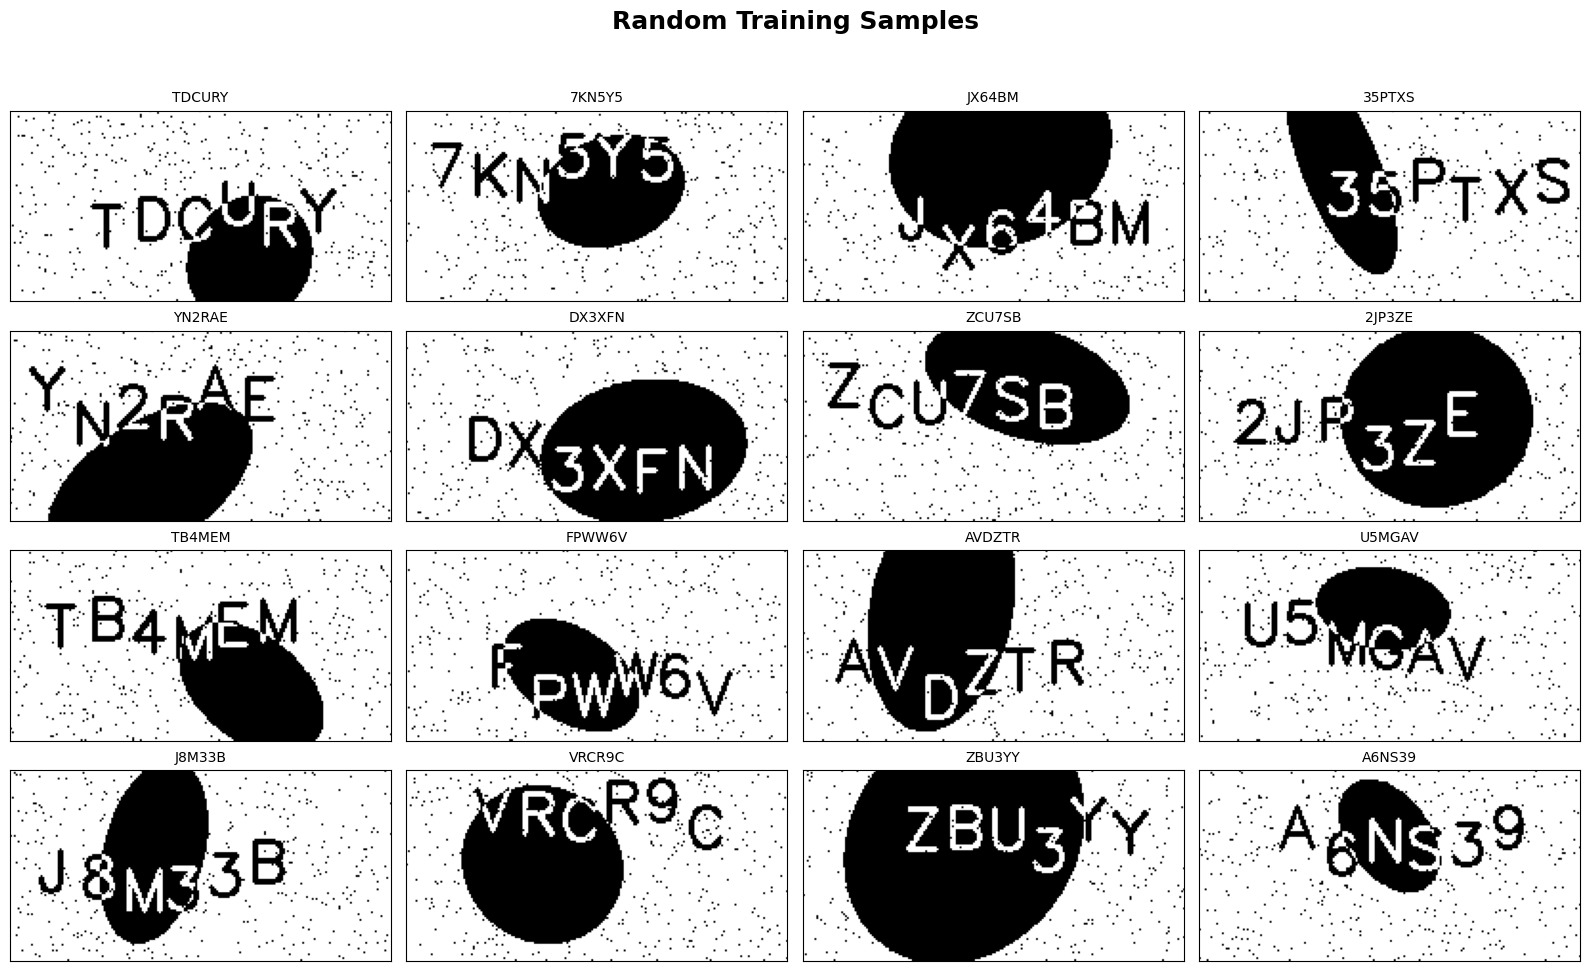

In [ ]:
# Purpose: Visualize a random subset of training samples along with their corresponding labels.

random.seed(42)

sample_count = min(16, len(dataset_df))

selected_indices = random.sample(
    population=range(len(dataset_df)),
    k=sample_count
)

sample_subset = (
    dataset_df
    .iloc[selected_indices]
    .reset_index(drop=True)
)

figure, axis_grid = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 10)
)

figure.suptitle(
    "Random Training Samples",
    fontsize=18,
    fontweight="bold"
)

for axis, (_, record) in zip(
    axis_grid.flatten(),
    sample_subset.iterrows()
):

    image_file = train_dir / str(record[image_col])

    try:
        image = Image.open(image_file).convert("L")

        axis.imshow(
            image,
            cmap="gray"
        )

        axis.set_title(
            str(record[label_col]),
            fontsize=10
        )

    except Exception:

        axis.text(
            0.5,
            0.5,
            "Image Unavailable",
            ha="center",
            va="center",
            transform=axis.transAxes
        )

        axis.set_title(
            "Load Failed",
            fontsize=9
        )

    axis.set_xticks([])
    axis.set_yticks([])

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

In [ ]:
# Purpose: Inspect image dimensions and color formats using a representative sample of training images.

random.seed(123)

available_images = [
    file.name
    for file in train_dir.iterdir()
    if file.is_file()
]

inspection_set = random.sample(
    available_images,
    k=min(50, len(available_images))
)

dimensions = []
color_modes = []

for image_name in inspection_set:

    image_path = train_dir / image_name

    try:
        with Image.open(image_path) as image:

            dimensions.append(
                (image.width, image.height)
            )

            color_modes.append(
                image.mode
            )

    except Exception as error:

        print(
            f"Skipped '{image_name}' due to read error: {error}"
        )

if len(dimensions) > 0:

    widths = [
        width
        for width, _ in dimensions
    ]

    heights = [
        height
        for _, height in dimensions
    ]

    print("Image Dimension Summary")

    print(
        f"Images Analyzed     : {len(dimensions)}"
    )

    print(
        f"Width Range         : {min(widths)} - {max(widths)}"
    )

    print(
        f"Average Width       : {np.mean(widths):.1f}"
    )

    print(
        f"Height Range        : {min(heights)} - {max(heights)}"
    )

    print(
        f"Average Height      : {np.mean(heights):.1f}"
    )

    print(
        f"Consistent Sizing   : {len(set(dimensions)) == 1}"
    )

    print(
        f"Image Modes Present : {sorted(set(color_modes))}"
    )

else:

    print(
        "No valid images were available for inspection."
    )

Image Dimension Summary
Images Analyzed     : 50
Width Range         : 200 - 200
Average Width       : 200.0
Height Range        : 100 - 100
Average Height      : 100.0
Consistent Sizing   : True
Image Modes Present : ['RGB']


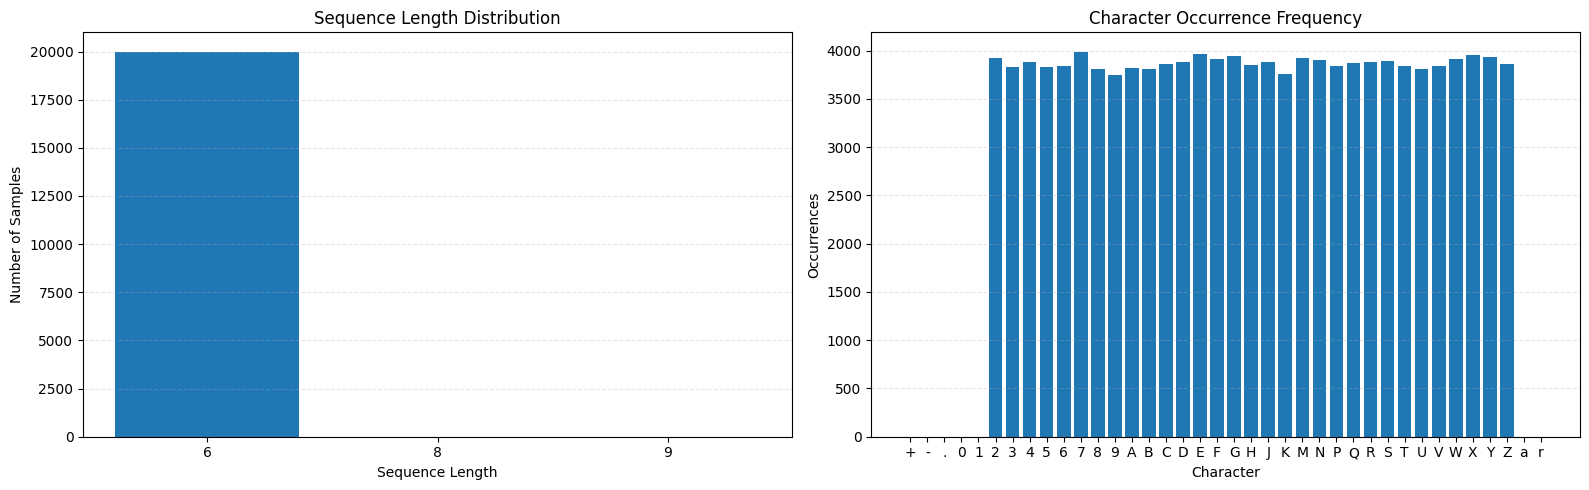

In [ ]:
# Purpose: Visualize sequence length distribution and character frequency statistics.

figure, plot_axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5)
)

# Sequence length distribution

plot_axes[0].bar(
    frequency_table.index.astype(str),
    frequency_table["Frequency"],
)

plot_axes[0].set_title(
    "Sequence Length Distribution"
)

plot_axes[0].set_xlabel(
    "Sequence Length"
)

plot_axes[0].set_ylabel(
    "Number of Samples"
)

plot_axes[0].grid(
    linestyle="--",
    alpha=0.3,
    axis="y"
)

# Character frequency analysis

character_stream = "".join(
    dataset_df[label_col]
    .astype(str)
)

character_frequency = (
    pd.Series(list(character_stream))
    .value_counts()
    .sort_index()
)

plot_axes[1].bar(
    character_frequency.index,
    character_frequency.values
)

plot_axes[1].set_title(
    "Character Occurrence Frequency"
)

plot_axes[1].set_xlabel(
    "Character"
)

plot_axes[1].set_ylabel(
    "Occurrences"
)

plot_axes[1].grid(
    linestyle="--",
    alpha=0.3,
    axis="y"
)

plt.tight_layout()

plt.show()

In [ ]:
# Purpose: Present a consolidated summary of the dataset characteristics.

train_sample_count = len(dataset_df)

test_sample_count = sum(
    file.is_file()
    for file in test_dir.iterdir()
)

sequence_category = (
    "Fixed Length"
    if length_stats.min() == length_stats.max()
    else "Variable Length"
)

available_modes = sorted(
    set(color_modes)
)

if len(available_modes) == 1:

    detected_mode = available_modes[0]

    image_mode = (
        "Grayscale"
        if detected_mode in {"L", "I", "I;16"}
        else detected_mode
    )

else:

    image_mode = (
        "Mixed Formats: "
        + ", ".join(available_modes)
    )

width_values = [
    width
    for width, _ in dimensions
]

height_values = [
    height
    for _, height in dimensions
]

width_range = (
    str(width_values[0])
    if len(set(width_values)) == 1
    else f"{min(width_values)} - {max(width_values)}"
)

height_range = (
    str(height_values[0])
    if len(set(height_values)) == 1
    else f"{min(height_values)} - {max(height_values)}"
)


print("DATASET OVERVIEW")

print(f"Training Samples      : {train_sample_count}")
print(f"Test Samples          : {test_sample_count}")

print(f"Sequence Type         : {sequence_category}")
print(f"Minimum Length        : {length_stats.min()}")
print(f"Maximum Length        : {length_stats.max()}")
print(f"Average Length        : {length_stats.mean():.2f}")

print(f"Vocabulary Size       : {len(vocabulary)}")
print(f"Vocabulary            : {vocabulary}")

print(f"Image Column          : {image_col}")
print(f"Label Column          : {label_col}")

print(f"Image Width Range     : {width_range}")
print(f"Image Height Range    : {height_range}")
print(f"Image Format          : {image_mode}")

DATASET OVERVIEW
Training Samples      : 20000
Test Samples          : 5000
Sequence Type         : Variable Length
Minimum Length        : 6
Maximum Length        : 9
Average Length        : 6.00
Vocabulary Size       : 38
Vocabulary            : ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Image Column          : image
Label Column          : text
Image Width Range     : 200
Image Height Range    : 100
Image Format          : RGB


In [ ]:
# Purpose: Define the character vocabulary and create lookup tables for CTC-based sequence decoding.

character_set = [
    "+",
    "-",
    ".",
    *list("0123456789"),
    *list("ABCDEFGHJKMNPQRSTUVWXYZ"),
    "a",
    "r",
]

ctc_blank_token = 0

char_to_idx = {
    symbol: position + 1
    for position, symbol in enumerate(character_set)
}

idx_to_char = {
    index: symbol
    for symbol, index in char_to_idx.items()
}

print(f"CTC Blank Token Index : {ctc_blank_token}")
print(f"Vocabulary Size       : {len(character_set)}")

print("\nCharacter-to-Index Mapping")

for symbol, index in char_to_idx.items():
    print(f"{repr(symbol):>4} → {index}")

CTC Blank Token Index : 0
Vocabulary Size       : 38

Character-to-Index Mapping
 '+' → 1
 '-' → 2
 '.' → 3
 '0' → 4
 '1' → 5
 '2' → 6
 '3' → 7
 '4' → 8
 '5' → 9
 '6' → 10
 '7' → 11
 '8' → 12
 '9' → 13
 'A' → 14
 'B' → 15
 'C' → 16
 'D' → 17
 'E' → 18
 'F' → 19
 'G' → 20
 'H' → 21
 'J' → 22
 'K' → 23
 'M' → 24
 'N' → 25
 'P' → 26
 'Q' → 27
 'R' → 28
 'S' → 29
 'T' → 30
 'U' → 31
 'V' → 32
 'W' → 33
 'X' → 34
 'Y' → 35
 'Z' → 36
 'a' → 37
 'r' → 38


In [ ]:
# Purpose: Create a PyTorch dataset for loading OCR images and converting labels into CTC-compatible index sequences.

import torch
from torch.utils.data import Dataset
from torchvision import transforms

class OCRDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_directory,
        char_to_idx,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.image_directory = Path(
            image_directory
        )

        self.char_to_idx = char_to_idx

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        sample = self.dataframe.iloc[index]

        image_path = (
            self.image_directory
            / str(sample[image_col])
        )

        if not image_path.exists():

            raise FileNotFoundError(
                f"Image file not found: {image_path}"
            )

        with Image.open(image_path) as image:

            image = image.convert("L")

            if self.transform is not None:

                image = self.transform(image)

            else:

                image = transforms.ToTensor()(image)

        label_text = str(
            sample[label_col]
        )

        encoded_label = []

        for character in label_text:

            if character not in self.char_to_idx:

                raise ValueError(
                    f"Unsupported character encountered: {repr(character)}"
                )

            encoded_label.append(
                self.char_to_idx[character]
            )

        target_tensor = torch.tensor(
            encoded_label,
            dtype=torch.long
        )

        return (
            image,
            target_tensor,
            len(encoded_label)
        )

In [ ]:
# Purpose: Prepare image transformations, create train-validation splits, and initialize DataLoaders.

from torch.utils.data import DataLoader, random_split
from torchvision import transforms

IMAGE_SIZE = (100, 320)
TRAIN_RATIO = 0.90
BATCH_SIZE = 32

preprocess = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

ocr_dataset = OCRDataset(
    dataset_df,
    train_dir,
    char_to_idx,
    transform=preprocess
)

num_train = int(
    TRAIN_RATIO * len(ocr_dataset)
)

num_val = len(ocr_dataset) - num_train

train_dataset, validation_dataset = random_split(
    dataset=ocr_dataset,
    lengths=[num_train, num_val],
    generator=torch.Generator().manual_seed(42)
)

def build_ctc_batch(samples):

    image_list, target_list, sequence_lengths = zip(*samples)

    batch_images = torch.stack(image_list)

    batch_targets = torch.cat(target_list)

    target_lengths = torch.as_tensor(
        sequence_lengths,
        dtype=torch.long
    )

    input_lengths = torch.full(
        size=(batch_images.size(0),),
        fill_value=10,
        dtype=torch.long
    )

    return (
        batch_images,
        batch_targets,
        input_lengths,
        target_lengths
    )

loader_settings = dict(
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    collate_fn=build_ctc_batch,
    **loader_settings
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    collate_fn=build_ctc_batch,
    **loader_settings
)

print(f"Training Set Size   : {len(train_dataset)}")
print(f"Validation Set Size : {len(validation_dataset)}")

Training Set Size   : 18000
Validation Set Size : 2000


In [ ]:
# Purpose: Define the CRNN architecture using a ResNet18 feature extractor, BiLSTM sequence model, and CTC output layer.

import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18

class OCRRecognitionModel(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        feature_extractor = resnet18(
            pretrained=False
        )

        feature_extractor.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.feature_extractor = nn.Sequential(
            feature_extractor.conv1,
            feature_extractor.bn1,
            feature_extractor.relu,
            feature_extractor.maxpool,
            feature_extractor.layer1,
            feature_extractor.layer2,
            feature_extractor.layer3,
            feature_extractor.layer4,
        )

        self.sequence_model = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=False
        )

        self.classifier = nn.Linear(
            in_features=512,
            out_features=num_classes
        )

    def forward(self, images):

        features = self.feature_extractor(
            images
        )

        features = features.mean(
            dim=2
        )

        sequence_input = features.permute(
            2, 0, 1
        )

        recurrent_output, _ = self.sequence_model(
            sequence_input
        )

        logits = self.classifier(
            recurrent_output
        )

        return F.log_softmax(
            logits,
            dim=2
        )

In [ ]:
# Purpose: Initialize the OCR model, verify tensor dimensions, and perform a forward-pass sanity check.

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = OCRRecognitionModel(
    num_classes=len(character_set) + 1
).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Execution Device      : {device}")
print(f"Trainable Parameters  : {parameter_count:,}")

sample_batch = next(
    iter(train_loader)
)

images, labels, input_lengths, label_lengths = sample_batch

images = images.to(device)

with torch.no_grad():

    predictions = model(images)

print(f"Input Tensor Shape    : {tuple(images.shape)}")
print(f"Output Tensor Shape   : {tuple(predictions.shape)}")

print(
    "\nExpected Layout: "
    "(sequence_length, batch_size, num_classes)"
)

assert (
    predictions.shape[2]
    == len(character_set) + 1
), "Mismatch detected in output class dimension."

print("Model validation check completed successfully.")

/home/anirudh/Desktop/cigproject/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/anirudh/Desktop/cigproject/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Execution Device      : cuda
Trainable Parameters  : 14,344,167
Input Tensor Shape    : (32, 1, 100, 320)
Output Tensor Shape   : (10, 32, 39)

Expected Layout: (sequence_length, batch_size, num_classes)
Model validation check completed successfully.


## 14. Model Training and Performance Evaluation

After preparing the dataset and defining the CRNN architecture, the next step is to train the model and evaluate its performance on unseen samples. During training, the model learns to map distorted image sequences to their corresponding text labels using the Connectionist Temporal Classification (CTC) loss function, which is well-suited for sequence prediction tasks where character-level alignment is not explicitly available.

To monitor the learning process, both training and validation losses are recorded across epochs. Tracking these metrics helps in understanding whether the model is learning meaningful patterns from the data and whether issues such as overfitting or underfitting are present. Validation performance is used as an indicator of how well the model generalizes beyond the training set.

In addition to numerical metrics, visualizations of the training history are included to observe the model's behaviour throughout the training process. These plots provide a clearer picture of convergence and help assess the effectiveness of the chosen architecture and training configuration.

In [ ]:
# Purpose: Configure CTC optimization, define sequence decoding, and implement training and validation routines.

ctc_criterion = nn.CTCLoss(
    blank=ctc_blank_token,
    zero_infinity=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4
)

def ctc_greedy_decode(logits):
    """
    Convert network outputs into readable text sequences
    using standard CTC greedy decoding.
    """

    predicted_indices = (
        torch.argmax(logits, dim=2)
        .cpu()
        .numpy()
    )

    decoded_sequences = []

    for sequence in predicted_indices.T:

        characters = []
        last_token = ctc_blank_token

        for token in sequence:

            if (
                token != ctc_blank_token
                and token != last_token
            ):
                characters.append(
                    idx_to_char.get(token, "?")
                )

            last_token = token

        decoded_sequences.append(
            "".join(characters)
        )

    return decoded_sequences


def train_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device
):
    """
    Execute one complete training epoch.
    """

    model.train()

    cumulative_loss = 0.0

    for batch in data_loader:

        images, targets, input_lengths, target_lengths = batch

        images = images.to(device)
        targets = targets.to(device)

        input_lengths = input_lengths.to(device)
        target_lengths = target_lengths.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = criterion(
            predictions,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()

        optimizer.step()

        cumulative_loss += (
            loss.item()
            * images.size(0)
        )

    return (
        cumulative_loss
        / len(data_loader.dataset)
    )


def evaluate_epoch(
    model,
    data_loader,
    criterion,
    device
):
    """
    Evaluate model performance on validation data.
    """

    model.eval()

    cumulative_loss = 0.0

    with torch.no_grad():

        for batch in data_loader:

            images, targets, input_lengths, target_lengths = batch

            images = images.to(device)
            targets = targets.to(device)

            input_lengths = input_lengths.to(device)
            target_lengths = target_lengths.to(device)

            predictions = model(images)

            loss = criterion(
                predictions,
                targets,
                input_lengths,
                target_lengths
            )

            cumulative_loss += (
                loss.item()
                * images.size(0)
            )

    return (
        cumulative_loss
        / len(data_loader.dataset)
    )

Epoch [1/2] | Train Loss: 2.7914 | Validation Loss: 2.1625
Epoch [2/2] | Train Loss: 1.6316 | Validation Loss: 1.2222


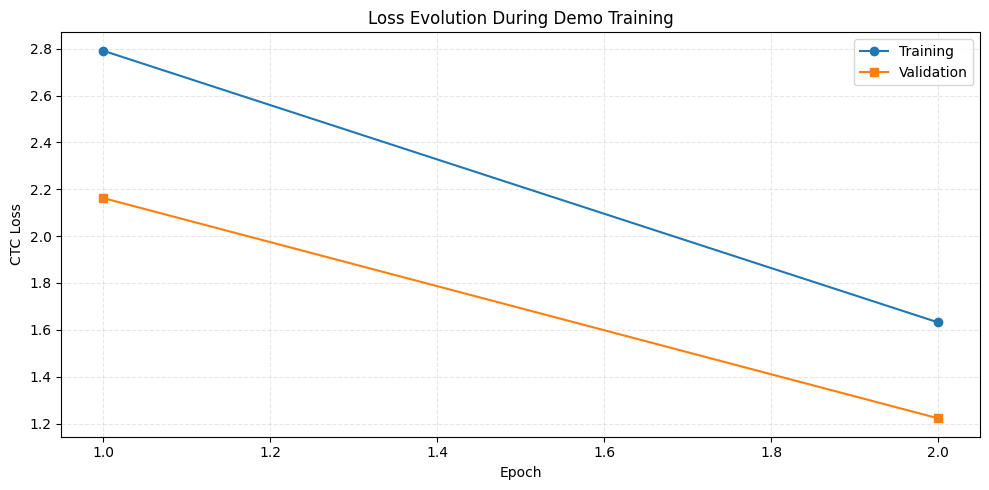


Example Predictions
Prediction 1: EUYJ5
Prediction 2: UTD58Y
Prediction 3: 3B2FYX
Prediction 4: TW9YQH
Prediction 5: USZWVW


In [ ]:
# Purpose: Perform a short training sanity check, visualize loss trends, and inspect sample predictions.

demo_model = OCRRecognitionModel(
    num_classes=len(character_set) + 1
).to(device)

demo_optimizer = torch.optim.Adam(
    demo_model.parameters(),
    lr=2e-4
)

demo_epochs = 2

training_history = {
    "training": [],
    "validation": []
}

for current_epoch in range(demo_epochs):

    epoch_train_loss = train_epoch(
        demo_model,
        train_loader,
        demo_optimizer,
        ctc_criterion,
        device
    )

    epoch_val_loss = evaluate_epoch(
        demo_model,
        validation_loader,
        ctc_criterion,
        device
    )

    training_history["training"].append(
        epoch_train_loss
    )

    training_history["validation"].append(
        epoch_val_loss
    )

    print(
        f"Epoch [{current_epoch + 1}/{demo_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Validation Loss: {epoch_val_loss:.4f}"
    )

# ------------------------------------------
# Loss Curve Visualization
# ------------------------------------------

epochs_axis = list(
    range(1, demo_epochs + 1)
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_axis,
    training_history["training"],
    marker="o",
    label="Training"
)

plt.plot(
    epochs_axis,
    training_history["validation"],
    marker="s",
    label="Validation"
)

plt.title(
    "Loss Evolution During Demo Training"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "CTC Loss"
)

plt.legend()

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()

plt.show()

# ------------------------------------------
# Prediction Inspection
# ------------------------------------------

validation_batch = next(
    iter(validation_loader)
)

images, labels, input_lengths, label_lengths = validation_batch

images = images.to(device)

with torch.no_grad():

    logits = demo_model(images)

sample_predictions = ctc_greedy_decode(
    logits[:10]
)

print("\nExample Predictions")

for sample_id, prediction in enumerate(
    sample_predictions[:, :5, :],
    start=1
):
    print(
        f"Prediction {sample_id}: {prediction}"
    )

Epoch [1/20] | Train: 2.7389 | Val: 1.9817 | Best: 1.9817
Epoch [2/20] | Train: 1.6927 | Val: 1.8691 | Best: 1.8691
Epoch [3/20] | Train: 1.1949 | Val: 0.8523 | Best: 0.8523
Epoch [4/20] | Train: 0.5761 | Val: 0.3312 | Best: 0.3312
Epoch [5/20] | Train: 0.2635 | Val: 0.2412 | Best: 0.2412
Epoch [6/20] | Train: 0.1859 | Val: 0.1731 | Best: 0.1731
Epoch [7/20] | Train: 0.1377 | Val: 0.1353 | Best: 0.1353
Epoch [8/20] | Train: 0.1033 | Val: 0.1082 | Best: 0.1082
Epoch [9/20] | Train: 0.0718 | Val: 0.1272 | Best: 0.1082
Epoch [10/20] | Train: 0.0465 | Val: 0.0604 | Best: 0.0604
Epoch [11/20] | Train: 0.0392 | Val: 0.0644 | Best: 0.0604
Epoch [12/20] | Train: 0.0269 | Val: 0.0426 | Best: 0.0426
Epoch [13/20] | Train: 0.0239 | Val: 0.0407 | Best: 0.0407
Epoch [14/20] | Train: 0.0210 | Val: 0.1077 | Best: 0.0407
Epoch [15/20] | Train: 0.0171 | Val: 0.0308 | Best: 0.0308
Epoch [16/20] | Train: 0.0178 | Val: 0.0458 | Best: 0.0308
Epoch [17/20] | Train: 0.0148 | Val: 0.0347 | Best: 0.0308
Epoch 

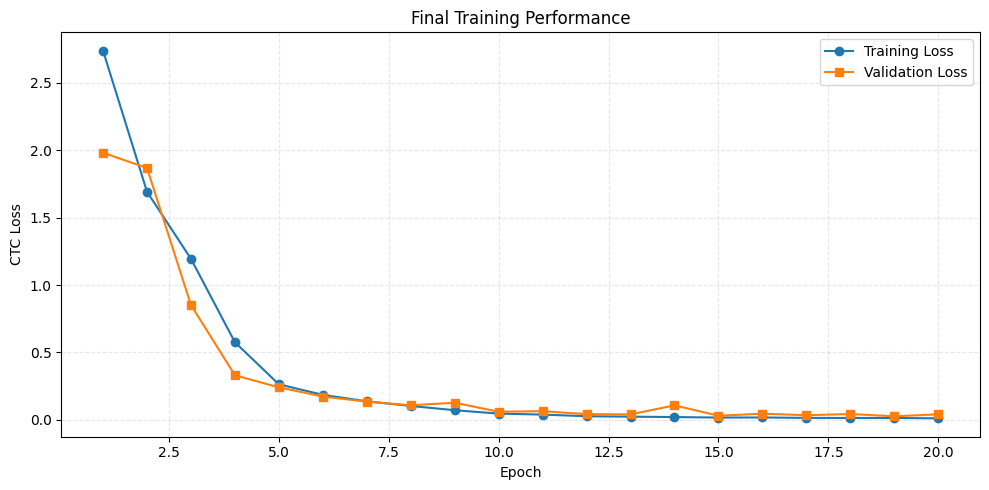


Best Validation Loss: 0.0264
Best Epoch: 19
Checkpoint Saved At: checkpoints/best_crnn_ctc.pth

Validation Predictions
1. EU
2. W7D
3. 3B2D
4. TM9
5. MSZM
6. X329
7. PXQ
8. 6439
9. 3Z5S
10. T
11. RCSQ
12. AT
13. 4P
14. R6S
15. SS7
16. N86H
17. 8C
18. 3BA
19. NRN
20. UQH
21. U7SH
22. N8Z
23. 628
24. 8A
25. FH
26. 38C
27. SR
28. ZUT
29. 8ED
30. WEF
31. R6G5
32. AK

Loading best checkpoint...

Best Checkpoint Predictions
1. EUY
2. W7D5
3. 3B2D
4. TM9
5. MSZM
6. X329
7. PXQ
8. 6439
9. 3Z5S
10. T
11. RCSQ
12. AT
13. 4P
14. R6S
15. SS7
16. N86H
17. 8C
18. 3BA
19. NRN
20. UQH
21. U7SH
22. N6Z
23. 628
24. 8A
25. FH
26. 38C
27. SR
28. ZUT
29. 8ED
30. WEF
31. R6G5
32. AK


In [ ]:
# Purpose: Train the final OCR model, apply checkpointing, perform early stopping, and evaluate the best saved model.

final_model = OCRRecognitionModel(
    num_classes=len(character_set) + 1
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=2e-4
)

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

max_epochs = 20
early_stop_patience = 5

best_validation_loss = float("inf")
best_epoch_number = 0
epochs_without_improvement = 0

training_log = {
    "training": [],
    "validation": []
}

checkpoint_directory = Path(
    "checkpoints"
)

checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True
)

checkpoint_file = (
    checkpoint_directory
    / "best_crnn_ctc.pth"
)

for epoch_index in range(max_epochs):

    current_train_loss = train_epoch(
        final_model,
        train_loader,
        final_optimizer,
        ctc_criterion,
        device
    )

    current_val_loss = evaluate_epoch(
        final_model,
        validation_loader,
        ctc_criterion,
        device
    )

    training_log["training"].append(
        current_train_loss
    )

    training_log["validation"].append(
        current_val_loss
    )

    lr_scheduler.step(
        current_val_loss
    )

    if current_val_loss < (
        best_validation_loss - 1e-6
    ):

        best_validation_loss = current_val_loss

        best_epoch_number = (
            epoch_index + 1
        )

        epochs_without_improvement = 0

        torch.save(
            final_model.state_dict(),
            checkpoint_file
        )

    else:

        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch_index + 1}/{max_epochs}] | "
        f"Train: {current_train_loss:.4f} | "
        f"Val: {current_val_loss:.4f} | "
        f"Best: {best_validation_loss:.4f}"
    )

    if (
        epochs_without_improvement
        >= early_stop_patience
    ):

        print(
            f"\nEarly stopping triggered "
            f"after {epoch_index + 1} epochs."
        )

        break

# -------------------------------------------------
# Training Curve Visualization
# -------------------------------------------------

completed_epochs = range(
    1,
    len(training_log["training"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    completed_epochs,
    training_log["training"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    completed_epochs,
    training_log["validation"],
    marker="s",
    label="Validation Loss"
)

plt.title(
    "Final Training Performance"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "CTC Loss"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print(
    f"\nBest Validation Loss: "
    f"{best_validation_loss:.4f}"
)

print(
    f"Best Epoch: "
    f"{best_epoch_number}"
)

print(
    f"Checkpoint Saved At: "
    f"{checkpoint_file}"
)

# -------------------------------------------------
# Prediction Examples
# -------------------------------------------------

validation_batch = next(
    iter(validation_loader)
)

images, labels, input_lengths, label_lengths = validation_batch

images = images.to(device)

with torch.no_grad():

    predictions = final_model(
        images
    )

decoded_predictions = ctc_greedy_decode(
    predictions[:, :5, :]
)

print("\nValidation Predictions")

for sample_number, text in enumerate(
    decoded_predictions,
    start=1
):
    print(
        f"{sample_number}. {text}"
    )

# -------------------------------------------------
# Reload Best Model
# -------------------------------------------------

print(
    "\nLoading best checkpoint..."
)

best_model = OCRRecognitionModel(
    num_classes=len(character_set) + 1
).to(device)

best_model.load_state_dict(
    torch.load(
        checkpoint_file,
        map_location=device
    )
)

best_model.eval()

with torch.no_grad():

    best_predictions = best_model(
        images
    )

best_decoded = ctc_greedy_decode(
    best_predictions[:, :5, :]
)

print(
    "\nBest Checkpoint Predictions"
)

for sample_number, text in enumerate(
    best_decoded,
    start=1
):
    print(
        f"{sample_number}. {text}"
    )

In [ ]:
# Purpose: Evaluate model performance using Character Error Rate (CER) and inspect prediction quality.

def edit_distance(reference_text, predicted_text):
    """
    Compute Levenshtein edit distance between two strings.
    """

    rows = len(reference_text)
    cols = len(predicted_text)

    distance_table = list(
        range(cols + 1)
    )

    for row_idx in range(1, rows + 1):

        previous_row = distance_table.copy()

        distance_table[0] = row_idx

        for col_idx in range(1, cols + 1):

            if (
                reference_text[row_idx - 1]
                == predicted_text[col_idx - 1]
            ):

                distance_table[col_idx] = (
                    previous_row[col_idx - 1]
                )

            else:

                distance_table[col_idx] = 1 + min(
                    previous_row[col_idx],
                    distance_table[col_idx - 1],
                    previous_row[col_idx - 1]
                )

    return distance_table[cols]


def calculate_cer(
    model,
    data_loader,
    idx_to_char,
    device
):
    """
    Calculate Character Error Rate on a dataset.
    """

    model.eval()

    total_edit_distance = 0
    total_characters = 0

    predicted_sequences = []
    target_sequences = []

    with torch.no_grad():

        for (
            images,
            labels_flat,
            input_lengths,
            label_lengths
        ) in data_loader:

            images = images.to(device)

            logits = model(images)

            decoded_predictions = (
                ctc_greedy_decode(logits)
            )

            start_idx = 0

            for sample_idx, seq_length in enumerate(
                label_lengths.tolist()
            ):

                target_ids = labels_flat[
                    start_idx:
                    start_idx + seq_length
                ].tolist()

                target_text = "".join(
                    idx_to_char.get(token, "?")
                    for token in target_ids
                )

                predicted_text = (
                    decoded_predictions[sample_idx]
                )

                total_edit_distance += (
                    edit_distance(
                        target_text,
                        predicted_text
                    )
                )

                total_characters += len(
                    target_text
                )

                predicted_sequences.append(
                    predicted_text
                )

                target_sequences.append(
                    target_text
                )

                start_idx += seq_length

    cer_score = (
        total_edit_distance / total_characters
        if total_characters > 0
        else 1.0
    )

    return (
        cer_score,
        predicted_sequences,
        target_sequences
    )


# ------------------------------------------
# Load Best Saved Model
# ------------------------------------------

evaluation_model = OCRRecognitionModel(
    num_classes=len(character_set) + 1
).to(device)

evaluation_model.load_state_dict(
    torch.load(
        Path("checkpoints") / "best_crnn_ctc.pth",
        map_location=device
    )
)

# ------------------------------------------
# Compute CER
# ------------------------------------------

validation_cer, predictions, targets = calculate_cer(
    evaluation_model,
    validation_loader,
    idx_to_char,
    device
)

print(
    f"Validation CER: "
    f"{validation_cer:.4f}"
)

print(
    f"Percentage CER: "
    f"{validation_cer * 100:.2f}%"
)

print(
    "\nLower CER indicates better recognition performance."
)

# ------------------------------------------
# Display Sample Predictions
# ------------------------------------------

print(
    "\nPrediction Samples"
)

print(
    f"{'Predicted':<18}"
    f"{'Ground Truth':<18}"
    f"{'Match'}"
)

print("-" * 50)

for predicted_text, target_text in zip(
    predictions[:10],
    targets[:10]
):

    status = (
        "✓"
        if predicted_text == target_text
        else "✗"
    )

    print(
        f"{predicted_text:<18}"
        f"{target_text:<18}"
        f"{status}"
    )

Validation CER: 0.0062
Percentage CER: 0.62%

Lower CER indicates better recognition performance.

Prediction Samples
Predicted         Ground Truth      Match
--------------------------------------------------
EUYYJ5            EUYYJ5            ✓
W7D56Y            W7D56Y            ✓
3B2DYN            3B2DYN            ✓
TM9YQH            TM9YQH            ✓
MSZMVM            MSZMVM            ✓
X329YU            X329YU            ✓
PXQACV            PXQACV            ✓
6439VX            6439VX            ✓
3Z5S2C            3Z5S2C            ✓
TSQJZ3            TSQJZ3            ✓


In [ ]:
# Purpose: Generate predictions for all test images and create the final submission file.

from torchvision import transforms as T
target_height = 100
target_width = 200

inference_transform = T.Compose([
    T.Resize(
        (target_height, target_width)
    ),
    T.ToTensor(),
    T.Normalize(
        mean=[0.5],
        std=[0.5]
    ),
])

# ------------------------------------------
# Prepare Best Model
# ------------------------------------------

best_model.eval()

test_image_names = sorted(
    file.name
    for file in test_dir.iterdir()
    if file.is_file()
    and file.suffix.lower() == ".png"
)

print(
    f"Discovered {len(test_image_names)} test images."
)

submission_records = []

inference_batch_size = 64

for batch_start in range(
    0,
    len(test_image_names),
    inference_batch_size
):

    current_files = test_image_names[
        batch_start:
        batch_start + inference_batch_size
    ]

    image_batch = []

    for image_name in current_files:

        image_path = test_dir / image_name

        with Image.open(image_path) as image:

            processed_image = inference_transform(
                image.convert("L")
            )

            image_batch.append(
                processed_image
            )

    batch_tensor = torch.stack(
        image_batch
    ).to(device)

    with torch.no_grad():

        logits = best_model(
            batch_tensor
        )

    decoded_text = ctc_greedy_decode(
        logits
    )

    for image_name, prediction in zip(
        current_files,
        decoded_text
    ):

        submission_records.append(
            {
                "image": image_name,
                "prediction": prediction
            }
        )

    processed_count = min(
        batch_start + inference_batch_size,
        len(test_image_names)
    )

    if batch_start % (
        inference_batch_size * 10
    ) == 0:

        print(
            f"Processed "
            f"{processed_count}/"
            f"{len(test_image_names)} images"
        )

# ------------------------------------------
# Save Submission
# ------------------------------------------

submission_df = pd.DataFrame(
    submission_records
)

output_file = Path(
    "submission.csv"
)

submission_df.to_csv(
    output_file,
    index=False
)

print(
    f"\nSubmission File: "
    f"{output_file.resolve()}"
)

print(
    f"Total Predictions: "
    f"{len(submission_df)}"
)

print(
    "\nPreview of Submission"
)

display(
    submission_df.head(10)
)

Discovered 5000 test images.
Processed 64/5000 images
Processed 704/5000 images
Processed 1344/5000 images
Processed 1984/5000 images
Processed 2624/5000 images
Processed 3264/5000 images
Processed 3904/5000 images
Processed 4544/5000 images

Submission File: /home/anirudh/Desktop/cigproject/submission.csv
Total Predictions: 5000

Preview of Submission


,image,prediction
0,test-0.png,WNWA
1,test-1.png,HS5H
2,test-10.png,KH6
3,test-100.png,C5ZWH
4,test-1000.png,NQHV
5,test-1001.png,R6RN
6,test-1002.png,KN67
7,test-1003.png,9W2P
8,test-1004.png,H5HZ
9,test-1005.png,HHK


In [ ]:
# Purpose: Verify the generated submission file and inspect its contents.

submission_preview = pd.read_csv(
    "submission.csv"
)

print(
    f"Submission Shape: "
    f"{submission_preview.shape}"
)

print(
    "\nFirst 10 Records"
)

display(
    submission_preview.head(10)
)

print(
    "\nMissing Value Summary"
)

print(
    submission_preview.isna().sum()
)

Submission Shape: (5000, 2)

First 10 Records


,image,prediction
0,test-0.png,WNWA
1,test-1.png,HS5H
2,test-10.png,KH6
3,test-100.png,C5ZWH
4,test-1000.png,NQHV
5,test-1001.png,R6RN
6,test-1002.png,KN67
7,test-1003.png,9W2P
8,test-1004.png,H5HZ
9,test-1005.png,HHK



Missing Value Summary
image         0
prediction    0
dtype: int64
